In [1]:
# ============================================
# 04_visualizaciones.ipynb — Visualizaciones
# Proyecto: DataZ Movility (Fase A — Bizi)
# Autor: Miguel
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import folium
from folium.plugins import HeatMap

plt.style.use("seaborn-v0_8")
sns.set_palette("viridis")

DATA_PROCESSED = Path("../data/processed")
OUTPUTS = Path("../outputs/graficos")
OUTPUTS.mkdir(parents=True, exist_ok=True)

print("Entorno cargado correctamente.")


Entorno cargado correctamente.


In [2]:
df = pd.read_csv(DATA_PROCESSED / "bizi_clean.csv")
df.head()


,station_id,station_name,status,bikes,slots,capacity,ratio_ocupacion,ocupacion_categoria,lon,lat,lastUpdated
0,279,193- Pza. La Ermita,IN_SERVICE,1,18,19,0.052632,baja,-0.911216,41.631495,2026-02-25 17:08:07+00:00
1,278,270- Delicias Autobuses,IN_SERVICE,0,19,19,0.000000,baja,-0.910784,41.659517,2026-02-25 17:08:07+00:00
2,277,150- Mrio. Siresa: Dr. Iranzo,IN_SERVICE,11,8,19,0.578947,media,-0.864099,41.647586,2026-02-25 17:08:07+00:00
3,274,190- Puerto Venecia Este,IN_SERVICE,26,15,41,0.634146,media,-0.883953,41.608225,2026-02-25 17:08:07+00:00
4,273,224- Manuel Viola,IN_SERVICE,3,16,19,0.157895,baja,-0.857295,41.659139,2026-02-25 17:08:07+00:00


In [3]:
# Centro aproximado de Zaragoza
center = [41.6488, -0.8891]

m = folium.Map(location=center, zoom_start=13, tiles="CartoDB positron")

for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=6,
        color="blue",
        fill=True,
        fill_color="blue",
        fill_opacity=0.7,
        popup=f"{row['station_name']}<br>Bicis: {row['bikes']}<br>Anclajes: {row['slots']}"
    ).add_to(m)

m


In [4]:
def color_ratio(r):
    if r >= 0.7:
        return "red"
    if r >= 0.3:
        return "orange"
    return "green"

m2 = folium.Map(location=center, zoom_start=13, tiles="CartoDB positron")

for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=7,
        color=color_ratio(row["ratio_ocupacion"]),
        fill=True,
        fill_color=color_ratio(row["ratio_ocupacion"]),
        fill_opacity=0.8,
        popup=f"{row['station_name']}<br>Ocupación: {row['ratio_ocupacion']:.2f}"
    ).add_to(m2)

m2


In [5]:
heat_data = df[["lat", "lon", "ratio_ocupacion"]].values.tolist()

m3 = folium.Map(location=center, zoom_start=13, tiles="CartoDB dark_matter")
HeatMap(heat_data, radius=15, blur=10).add_to(m3)

m3


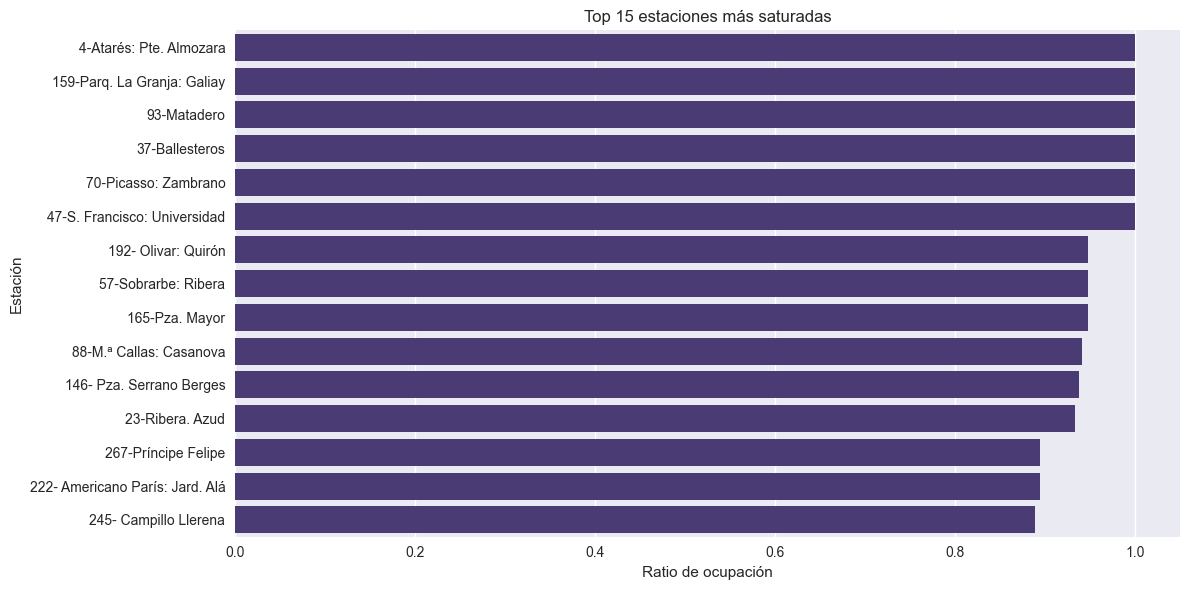

In [6]:
top15 = df.sort_values("ratio_ocupacion", ascending=False).head(15)

plt.figure(figsize=(12,6))
sns.barplot(data=top15, x="ratio_ocupacion", y="station_name")
plt.title("Top 15 estaciones más saturadas")
plt.xlabel("Ratio de ocupación")
plt.ylabel("Estación")
plt.tight_layout()
plt.savefig(OUTPUTS / "top15_saturadas.png", dpi=300)
plt.show()


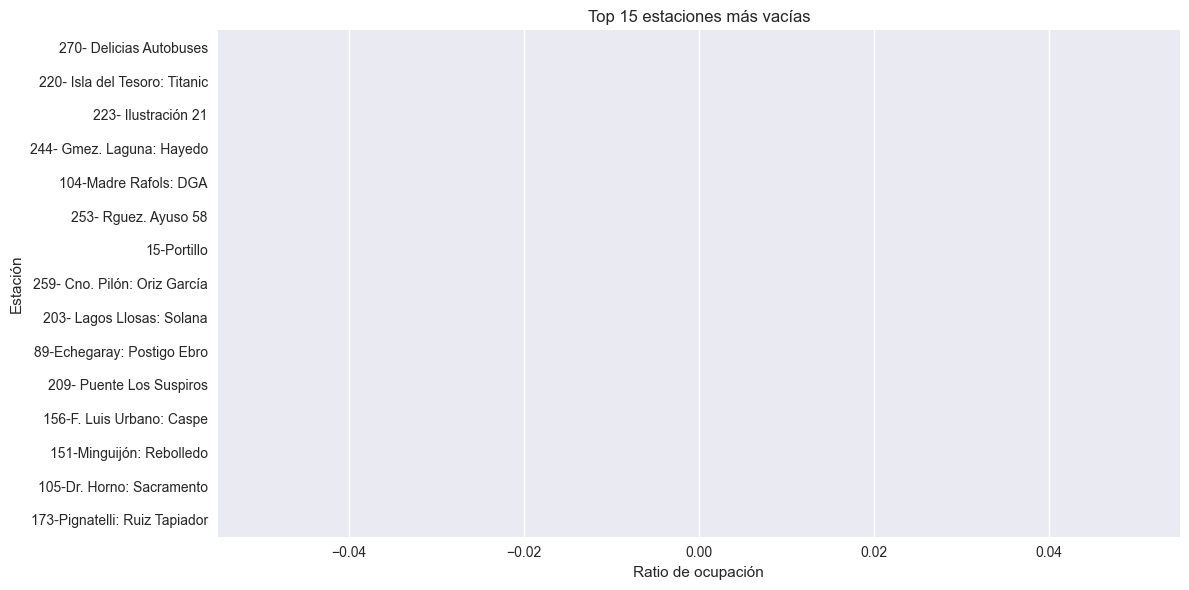

In [7]:
bottom15 = df.sort_values("ratio_ocupacion", ascending=True).head(15)

plt.figure(figsize=(12,6))
sns.barplot(data=bottom15, x="ratio_ocupacion", y="station_name")
plt.title("Top 15 estaciones más vacías")
plt.xlabel("Ratio de ocupación")
plt.ylabel("Estación")
plt.tight_layout()
plt.savefig(OUTPUTS / "top15_vacias.png", dpi=300)
plt.show()


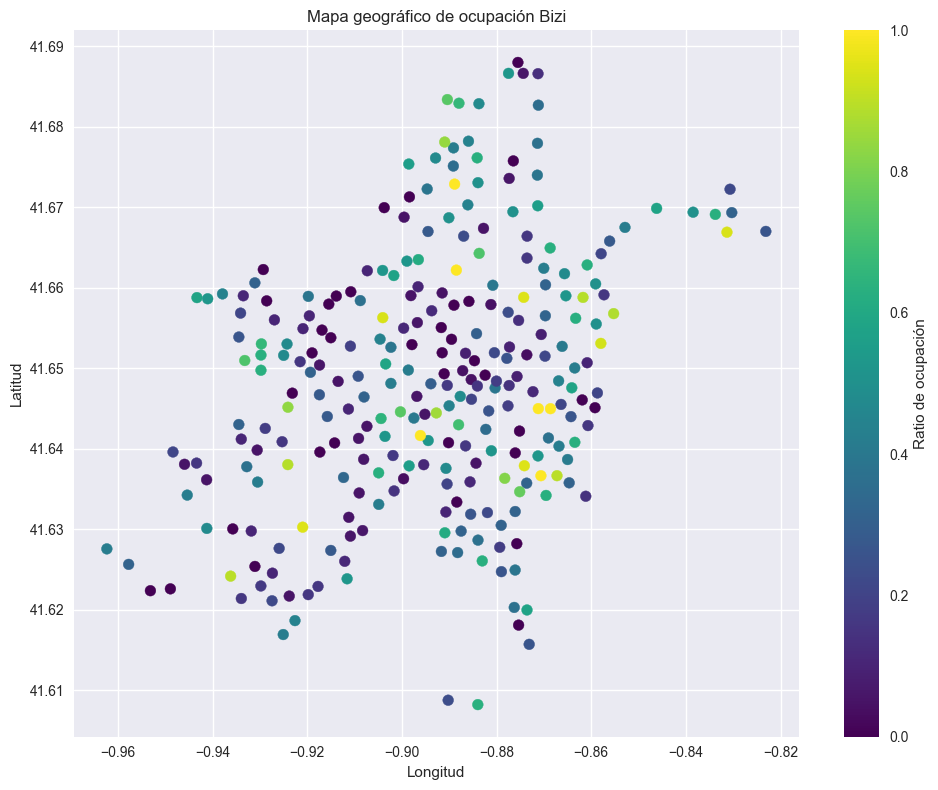

In [8]:
plt.figure(figsize=(10,8))
plt.scatter(df["lon"], df["lat"], c=df["ratio_ocupacion"], cmap="viridis", s=60)
plt.colorbar(label="Ratio de ocupación")
plt.title("Mapa geográfico de ocupación Bizi")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.tight_layout()
plt.savefig(OUTPUTS / "mapa_scatter_ocupacion.png", dpi=300)
plt.show()


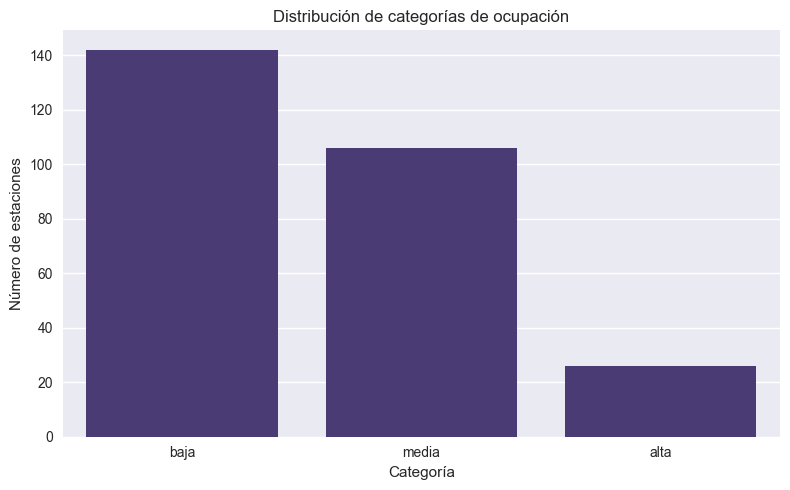

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="ocupacion_categoria")
plt.title("Distribución de categorías de ocupación")
plt.xlabel("Categoría")
plt.ylabel("Número de estaciones")
plt.tight_layout()
plt.savefig(OUTPUTS / "categorias_ocupacion.png", dpi=300)
plt.show()


In [10]:
m4 = folium.Map(location=center, zoom_start=13, tiles="OpenStreetMap")

for _, row in df.iterrows():
    icon_color = "green" if row["ocupacion_categoria"] == "baja" else \
                 "orange" if row["ocupacion_categoria"] == "media" else "red"

    folium.Marker(
        location=[row["lat"], row["lon"]],
        popup=f"{row['station_name']}<br>Ocupación: {row['ratio_ocupacion']:.2f}",
        icon=folium.Icon(color=icon_color)
    ).add_to(m4)

m4


In [11]:
df.to_csv(DATA_PROCESSED / "bizi_visual_ready.csv", index=False)
print("Dataset enriquecido guardado.")


Dataset enriquecido guardado.
